In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') 

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
#Cleaning
#Parse dates so we can group by month
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

#Check for missing values and duplicate rows
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

#Drop the index column as it carries no information
df = df.drop(columns=['Row ID'])

#Add a month period column used repeatedly below
df['Month'] = df['Order Date'].dt.to_period('M')

print("\nCleaned shape:", df.shape)
print("Date range:", df['Order Date'].min().date(), "to", df['Order Date'].max().date())
df.dtypes

Missing values total: 0
Duplicate rows: 0

Cleaned shape: (9994, 21)
Date range: 2014-01-03 to 2017-12-30


Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Month                 period[M]
dtype: object

In [17]:
#Save
df.to_csv('cleaned_superstore.csv', index=False)
print("Saved cleaned_superstore.csv")

Saved cleaned_superstore.csv


# Task 1

In [22]:
# Total sales summarized by month
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
print(monthly_sales.head())
print("\nNumber of months:", len(monthly_sales))

Month
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

Number of months: 48


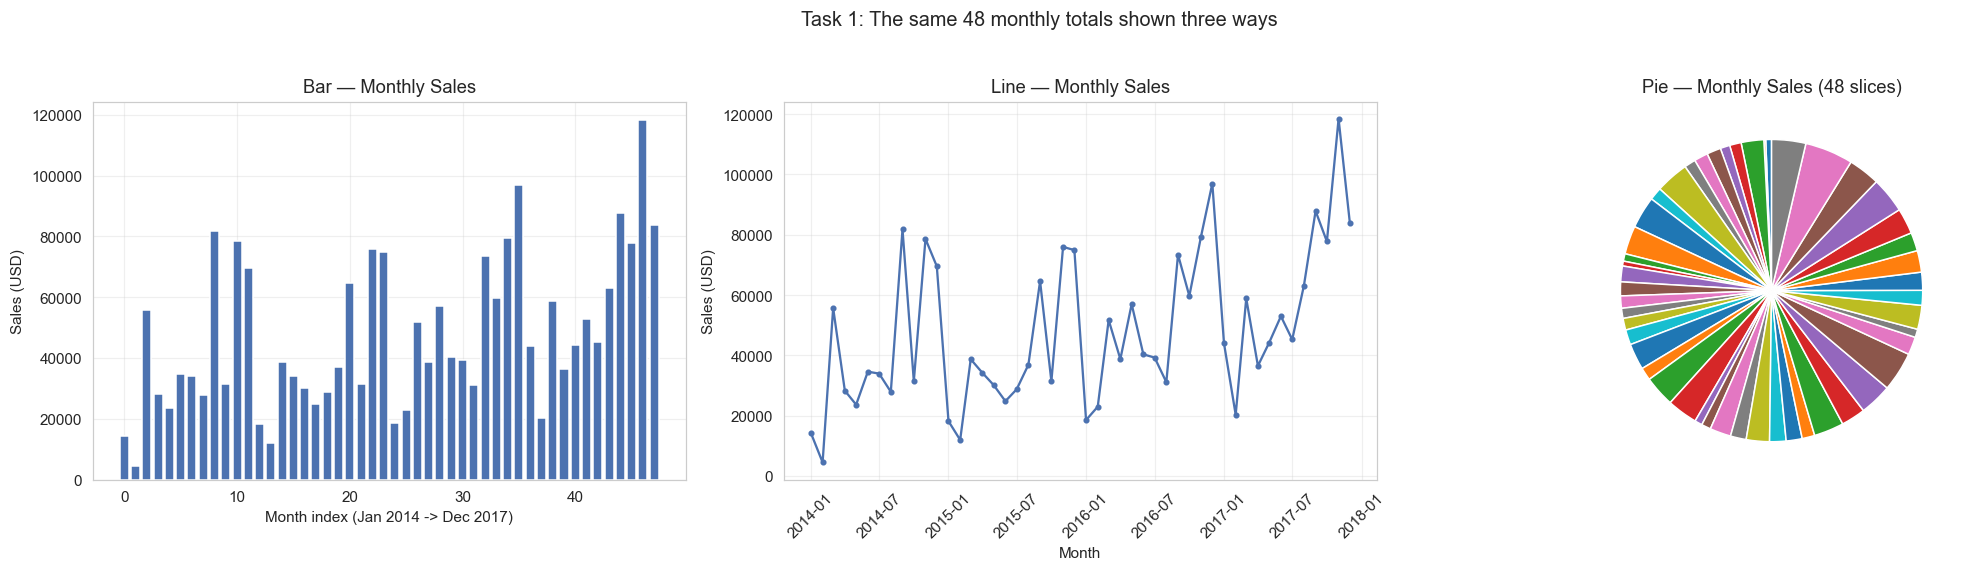

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].bar(range(len(monthly_sales)), monthly_sales.values, color='#4C72B0')
axes[0].set_title('Bar — Monthly Sales')
axes[0].set_xlabel('Month index (Jan 2014 -> Dec 2017)')
axes[0].set_ylabel('Sales (USD)')

axes[1].plot(monthly_sales.index, monthly_sales.values, color='#4C72B0', marker='o', markersize=3)
axes[1].set_title('Line — Monthly Sales')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Sales (USD)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].pie(monthly_sales.values, startangle=90)
axes[2].set_title(f'Pie — Monthly Sales ({len(monthly_sales)} slices)')
axes[2].grid(False)

plt.suptitle('Task 1: The same 48 monthly totals shown three ways', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

### Answer

Line chart is the best Time is ordered and continuous, and the connecting line encodes that directly: the slope between two points is the rate of change. The Q4 spike each year and the overall growth from 2014 to 2017 are both visible immediately.

Bar chart works, but poorly The heights are accurate, so individual months can still be read off precisely. But with 48 bars it gets noisy, and bars imply separate categories rather than a sequence, so the reader has to connect the tops mentally to see a trend.

Pie chart hides the trend completely A pie shows part-to-whole and has no time axis, so the order of months is lost once the circle wraps around. With 48 slices at roughly 2% each, the angles are too similar to compare.

# Task 2

### 2.1

Sub-Category
Binders    203412.733
Tables     206965.532
Storage    223843.608
Chairs     328449.103
Phones     330007.054
Name: Sales, dtype: float64


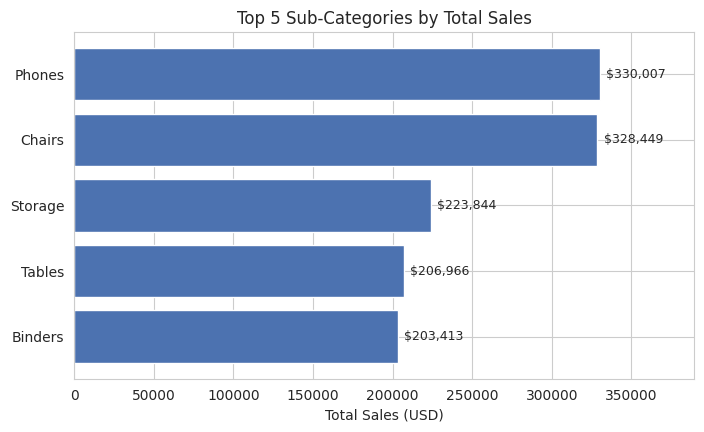

In [6]:
top5 = df.groupby('Sub-Category')['Sales'].sum().nlargest(5).sort_values()
print(top5)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top5.index, top5.values, color='#4C72B0')
ax.set_xlabel('Total Sales (USD)')
ax.set_title('Top 5 Sub-Categories by Total Sales')
for i, v in enumerate(top5.values):
    ax.text(v + 4000, i, f'${v:,.0f}', va='center', fontsize=9)
ax.set_xlim(0, top5.max() * 1.18)
plt.show()

**Justification.** A bar chart shows each value as a bar length starting from zero. Length is the easiest thing for our eyes to compare, and starting from zero means a bar twice as long really is twice the value. So comparing Phones to Chairs is just comparing two lengths.

A pie chart would make us compare slice angles instead. Phones (\$330.0k) and Chairs (\$328.4k) are only 0.5% apart, so their slices would look identical and we could not tell which is bigger. A radar chart is even worse, because each value sits on its own axis and what we end up looking at is the overall shape, not the individual numbers.


### 2.2 

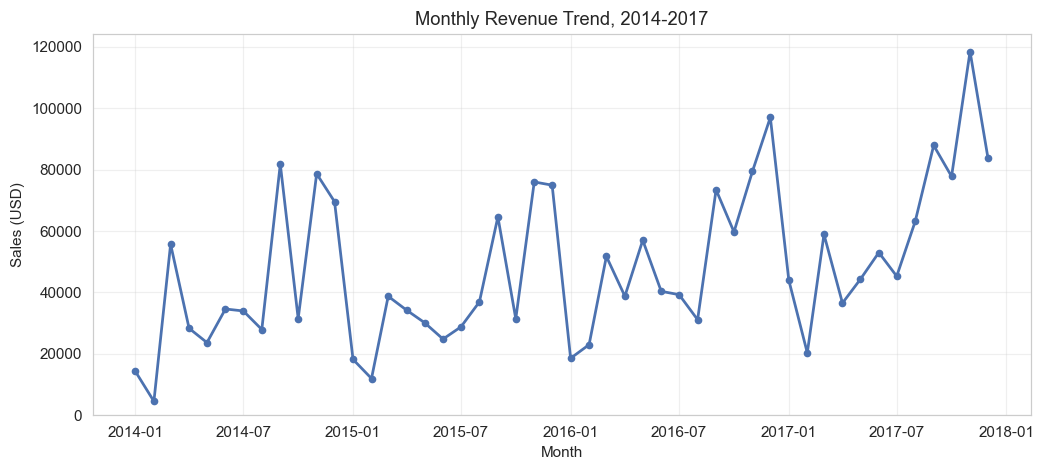

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_sales.index, monthly_sales.values,
        color='#4C72B0', linewidth=1.8, marker='o', markersize=4)
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD)')
ax.set_title('Monthly Revenue Trend, 2014-2017')
ax.set_ylim(0)  
plt.show()

**Justification.** A line chart treats months as one continuous sequence. The line going up or down between two points directly shows whether sales rose or fell that month, and the Q4 peaks read as a repeating seasonal pattern instead of a few unrelated tall values.

A bar chart with 48 months would turn into a crowded row of thin bars. The gaps between them mean nothing but still draw the eye, and because bars look like separate categories, months stop feeling connected to each other. The reader has to work out the trend instead of just seeing it.

### 2.3

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64


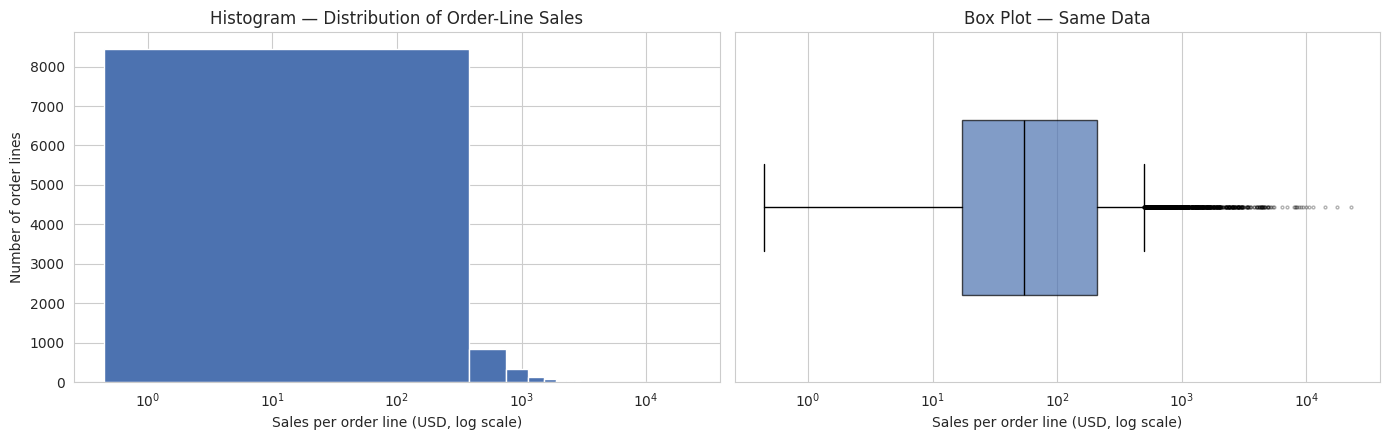

In [8]:
sales = df['Sales']
print(sales.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Histogram - log x-axis because the distribution is extremely right-skewed
axes[0].hist(sales, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sales per order line (USD, log scale)')
axes[0].set_ylabel('Number of order lines')
axes[0].set_title('Histogram — Distribution of Order-Line Sales')

# Box plot of the same data
axes[1].boxplot(sales, vert=False, widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                medianprops=dict(color='black'),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_xscale('log')
axes[1].set_xlabel('Sales per order line (USD, log scale)')
axes[1].set_yticks([])
axes[1].set_title('Box Plot — Same Data')

plt.tight_layout()
plt.show()

**Justification.** A histogram shows the whole shape of the data. We can see that most order lines are under \$100, while a few stretch all the way past \$20,000 the data is heavily skewed to the right. The box plot adds to this by showing the median (\$54.49) and the middle 50% of values in a compact way.

A "bar of averages" would squash all 9,994 values into one number (mean \$229.86). Because the data is so skewed, that average is actually higher than 75% of the orders, so it describes almost none of them. It would hide the skew, the spread, and the outliers which are exactly what the question is asking about.

### 2.4

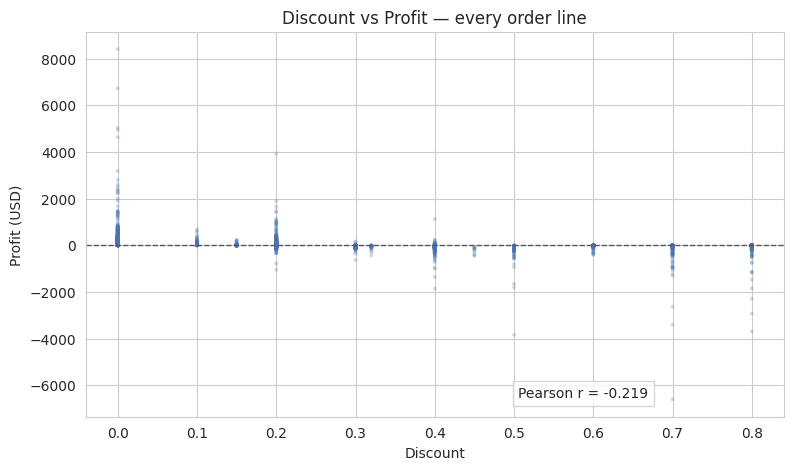

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['Discount'], df['Profit'], s=8, alpha=0.25, color='#4C72B0',
           edgecolors='none')
ax.axhline(0, color='#555555', linewidth=1, linestyle='--')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit (USD)')
ax.set_title('Discount vs Profit — every order line')

corr = df['Discount'].corr(df['Profit'])
ax.text(0.62, 0.05, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cccccc'))
plt.show()

**Justification.** A scatter plot draws one dot per order line, so we see both variables together. Between 0% and 20% discount the dots stay close to zero and mostly positive, but from 30% upward they fan out into bigger and bigger losses. The spread itself is part of the answer, not just where the middle sits.

A line chart would fail for two reasons. First, it needs one value per discount level, so all that spread would be thrown away and the spread is what the question is about. Second, the connecting lines would suggest a smooth relationship between one discount level and the next. But discount here is just a few fixed values the shop used (0%, 10%, 20%, and so on), not a smoothly changing input.

# Task 3

In [10]:
# The three aggregations used in this task
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_cat   = df.pivot_table(index='Region', columns='Category',
                              values='Sales', aggfunc='sum')
monthly_profit = df.groupby('Month')['Profit'].sum()
monthly_profit.index = monthly_profit.index.to_timestamp()

print(region_sales, "\n")
print(region_cat.round(0), "\n")
print("Monthly profit range:", round(monthly_profit.min(), 2), "to", round(monthly_profit.max(), 2))

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64 

Category  Furniture  Office Supplies  Technology
Region                                          
Central    163797.0         167026.0    170416.0
East       208291.0         205516.0    264974.0
South      117299.0         125651.0    148772.0
West       252613.0         220853.0    251992.0 

Monthly profit range: -3281.01 to 17885.31


### 3(a) 

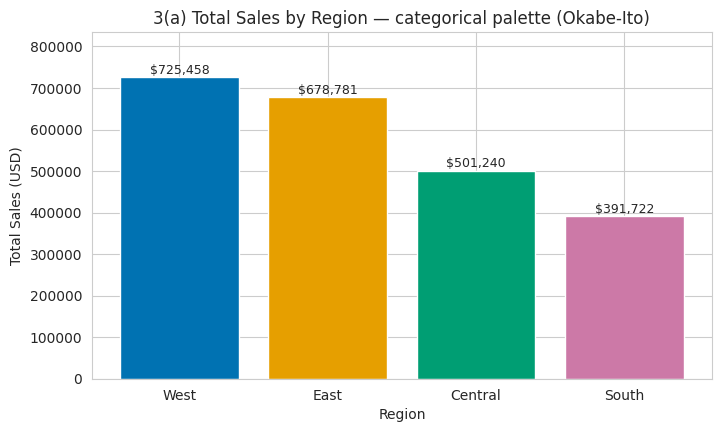

In [11]:
# Okabe-Ito colorblind-safe categorical palette
CATEGORICAL = ['#0072B2', '#E69F00', '#009E73', '#CC79A7']   # blue, orange, green, pink

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(region_sales.index, region_sales.values, color=CATEGORICAL)
ax.set_ylabel('Total Sales (USD)')
ax.set_xlabel('Region')
ax.set_title('3(a) Total Sales by Region — categorical palette (Okabe-Ito)')
for b, v in zip(bars, region_sales.values):
    ax.text(b.get_x() + b.get_width()/2, v + 8000, f'${v:,.0f}',
            ha='center', fontsize=9)
ax.set_ylim(0, region_sales.max() * 1.15)
plt.show()

**Why this palette.** Region is a nominal variable West is not "more" than East so the
colors must be equally salient with no implied ranking. Four distinct hues of similar
saturation satisfy that. A rainbow/viridis gradient here would imply an ordering that does
not exist. Note also that the bars are directly labelled, so color is decorative rather than
load-bearing: the chart still works in greyscale.

### 3(b)

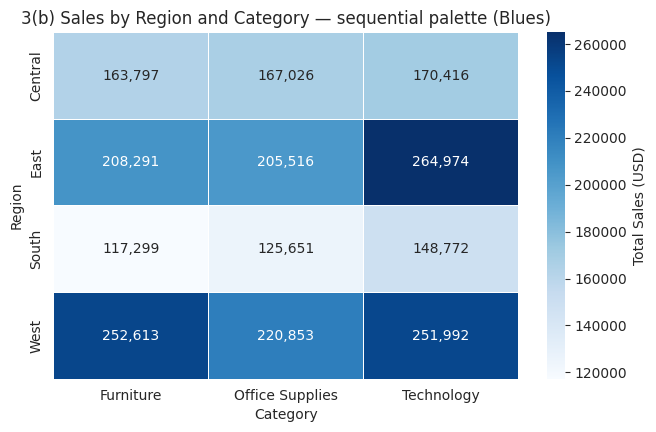

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.heatmap(region_cat, annot=True, fmt=',.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Total Sales (USD)'}, ax=ax)
ax.set_title('3(b) Sales by Region and Category — sequential palette (Blues)')
ax.set_ylabel('Region')
ax.set_xlabel('Category')
plt.show()

**Why this palette.** Sales is a magnitude with a natural low→high order and no meaningful
midpoint, so a single-hue light-to-dark ramp is correct: lightness maps monotonically to value,
which is the one channel humans read ordinally without training. Every cell is also annotated
with its number, satisfying the manual's "don't rely on color alone" rule the exact values
survive even if the color is lost.

### 3(c) 

Months with a net loss: 2 of 48


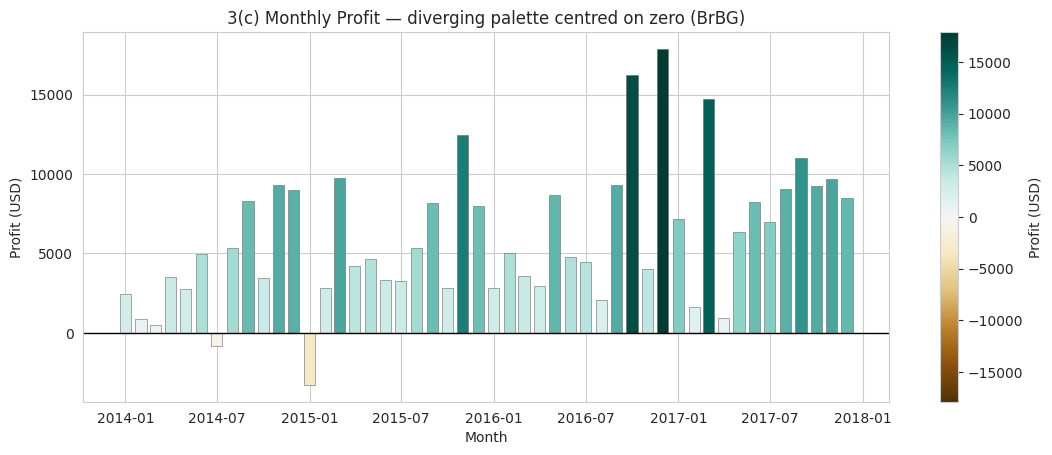

In [13]:
# Diverging around zero: brown-teal (colorblind-safe, avoids the red/green trap)
vmax = np.abs(monthly_profit.values).max()
norm = plt.Normalize(vmin=-vmax, vmax=vmax)      # symmetric so 0 lands on the neutral midpoint
cmap = plt.get_cmap('BrBG')
colors = [cmap(norm(v)) for v in monthly_profit.values]

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.bar(monthly_profit.index, monthly_profit.values, width=22,
       color=colors, edgecolor='#666666', linewidth=0.4)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Profit (USD)')
ax.set_xlabel('Month')
ax.set_title('3(c) Monthly Profit — diverging palette centred on zero (BrBG)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='Profit (USD)')

n_loss = (monthly_profit < 0).sum()
print(f"Months with a net loss: {n_loss} of {len(monthly_profit)}")
plt.show()

**Why this palette.** Profit has a natural, meaningful zero: above it the business made money,
below it lost money. A diverging scheme encodes that by putting a neutral midpoint at zero and
running two different hues outward, so both the *sign* and the *magnitude* are readable at a
glance. The normalization is deliberately symmetric (`-vmax` to `+vmax`) — if it were not, zero
would not land on the neutral color and a small loss could be shaded the same as a small profit.
I chose brown–teal rather than the conventional red–green precisely because of the manual's
warning about red-green deficiency; the bars also sit above or below a drawn zero line, so
position encodes the sign redundantly.

# Task 4

### 4(a) WCAG contrast ratio

The WCAG 2.x formula: convert each sRGB channel to a linear value, take the weighted
relative luminance `L = 0.2126R + 0.7152G + 0.0722B`, then the ratio is
`(L_light + 0.05) / (L_dark + 0.05)`. It ranges from 1:1 (identical) to 21:1 (black on white).

In [14]:
def hex_to_rgb(hex_color):
    """'#0072B2' -> (0, 114, 178)"""
    h = hex_color.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))


def relative_luminance(rgb):
    """WCAG relative luminance of an 8-bit sRGB triple."""
    channels = []
    for value in rgb:
        s = value / 255.0
        # Undo the sRGB gamma encoding to get linear light
        linear = s / 12.92 if s <= 0.03928 else ((s + 0.055) / 1.055) ** 2.4
        channels.append(linear)
    r, g, b = channels
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def contrast_ratio(color1, color2):
    """WCAG contrast ratio between two colors (hex strings or RGB tuples)."""
    rgb1 = hex_to_rgb(color1) if isinstance(color1, str) else color1
    rgb2 = hex_to_rgb(color2) if isinstance(color2, str) else color2
    l1, l2 = relative_luminance(rgb1), relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)


# Sanity checks against known values
print("black on white :", round(contrast_ratio('#000000', '#FFFFFF'), 2), "(expected 21.0)")
print("white on white :", round(contrast_ratio('#FFFFFF', '#FFFFFF'), 2), "(expected 1.0)")
print("#767676 on white:", round(contrast_ratio('#767676', '#FFFFFF'), 2), "(expected ~4.54)")

black on white : 21.0 (expected 21.0)
white on white : 1.0 (expected 1.0)
#767676 on white: 4.54 (expected ~4.54)


In [15]:
# Test every color used in Task 3 against the white chart background
WHITE = '#FFFFFF'
AA_THRESHOLD = 4.5

test_colors = {
    '3(a) West  (blue)':    '#0072B2',
    '3(a) East  (orange)':  '#E69F00',
    '3(a) Central (green)': '#009E73',
    '3(a) South (pink)':    '#CC79A7',
}

# Pull the actual endpoint and midpoint colors out of the Task 3 colormaps
for name, cm, pts in [('3(b) Blues', 'Blues', [0.15, 0.5, 0.9]),
                      ('3(c) BrBG',  'BrBG',  [0.0, 0.5, 1.0])]:
    cmap_obj = plt.get_cmap(cm)
    for p in pts:
        rgba = cmap_obj(p)
        rgb = tuple(int(round(x * 255)) for x in rgba[:3])
        test_colors[f'{name} @ {p:.2f}'] = '#%02X%02X%02X' % rgb

rows = []
for label, hexc in test_colors.items():
    ratio = contrast_ratio(hexc, WHITE)
    rows.append({'Element': label, 'Color': hexc,
                 'Contrast vs white': round(ratio, 2),
                 'Passes 4.5:1 AA': 'PASS' if ratio >= AA_THRESHOLD else 'FAIL'})

contrast_report = pd.DataFrame(rows)
contrast_report

,Element,Color,Contrast vs white,Passes 4.5:1 AA
0,3(a) West (blue),#0072B2,5.19,PASS
1,3(a) East (orange),#E69F00,2.25,FAIL
2,3(a) Central (green),#009E73,3.42,FAIL
3,3(a) South (pink),#CC79A7,3.06,FAIL
4,3(b) Blues @ 0.15,#D9E8F5,1.25,FAIL
5,3(b) Blues @ 0.50,#6AAED6,2.43,FAIL
6,3(b) Blues @ 0.90,#084A91,8.75,PASS
7,3(c) BrBG @ 0.00,#543005,11.65,PASS
8,3(c) BrBG @ 0.50,#F4F5F5,1.09,FAIL
9,3(c) BrBG @ 1.00,#003C30,12.43,PASS


In [16]:
fails = contrast_report[contrast_report['Passes 4.5:1 AA'] == 'FAIL']
print(f"{len(fails)} of {len(contrast_report)} tested colors FAIL the 4.5:1 AA threshold:\n")
for _, r in fails.iterrows():
    print(f"  - {r['Element']:<24} {r['Color']}   {r['Contrast vs white']}:1")

6 of 10 tested colors FAIL the 4.5:1 AA threshold:

  - 3(a) East  (orange)      #E69F00   2.25:1
  - 3(a) Central (green)     #009E73   3.42:1
  - 3(a) South (pink)        #CC79A7   3.06:1
  - 3(b) Blues @ 0.15        #D9E8F5   1.25:1
  - 3(b) Blues @ 0.50        #6AAED6   2.43:1
  - 3(c) BrBG @ 0.50         #F4F5F5   1.09:1


The 4.5:1 AA rule applies to text and small graphics, not to large filled shapes (those only need 3:1). Checking every colour from Task 3 against the white background:

Blue (#0072B2, 5.19:1) passes. It is safe for text, thin lines, or small markers.

Green (#009E73, 3.42:1) and pink (#CC79A7, 3.06:1) fail 4.5:1 but clear 3:1, so they are fine as bar fills, just not as text.

Orange (#E69F00, 2.25:1) fails both thresholds. It is the weakest colour in the palette and needs its outline and label to stay readable.

The light end of every gradient fails badly, which is unavoidable, since a light-to-dark ramp has to start near white. That is why the heatmap cells carry black number labels and the diverging bars have grey outlines.

Fixes applied: value labels on the bars, numbers inside every heatmap cell, and a zero line plus outlines on the diverging chart. Wherever a weak colour carries meaning, something other than colour carries it too.

### 4(b) Red/green chart → colorblind simulation → accessible fix

First, build the chart the *wrong* way: loss vs gain encoded with red and green only.

In [17]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(subcat_profit)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


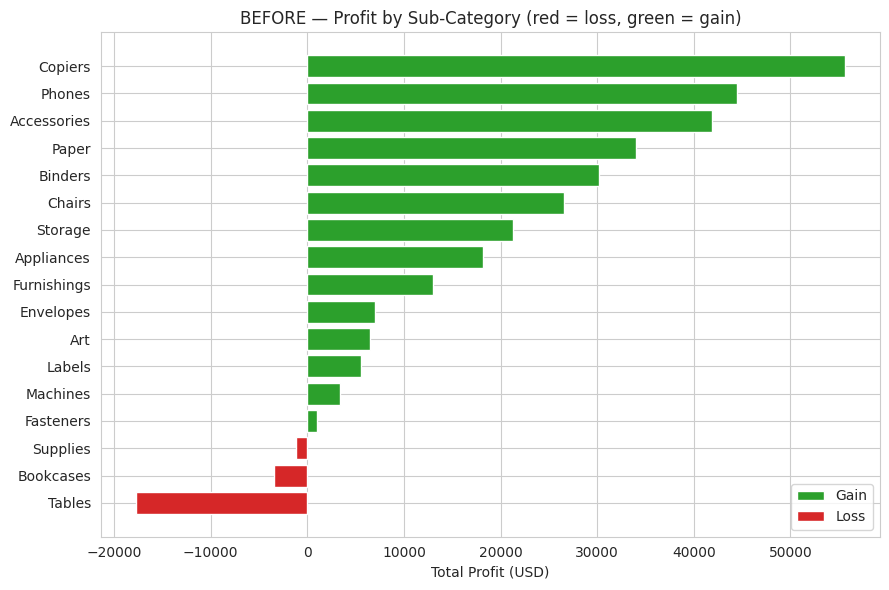

In [18]:
# --- BEFORE: meaning encoded by red vs green ALONE ---
RED, GREEN = '#D62728', '#2CA02C'

fig, ax = plt.subplots(figsize=(9, 6))
colors_rg = [RED if v < 0 else GREEN for v in subcat_profit.values]
bars = ax.barh(subcat_profit.index, subcat_profit.values, color=colors_rg)
ax.set_xlabel('Total Profit (USD)')
ax.set_title('BEFORE — Profit by Sub-Category (red = loss, green = gain)')
# The data is sorted ascending, so bars[0] is a loss bar and bars[-1] is a gain bar.
# Passing the real bars to legend() avoids needing a separate patch object.
ax.legend([bars[-1], bars[0]], ['Gain', 'Loss'], loc='lower right')
plt.tight_layout()
fig.savefig('task4_before.png', dpi=120, bbox_inches='tight')
plt.show()

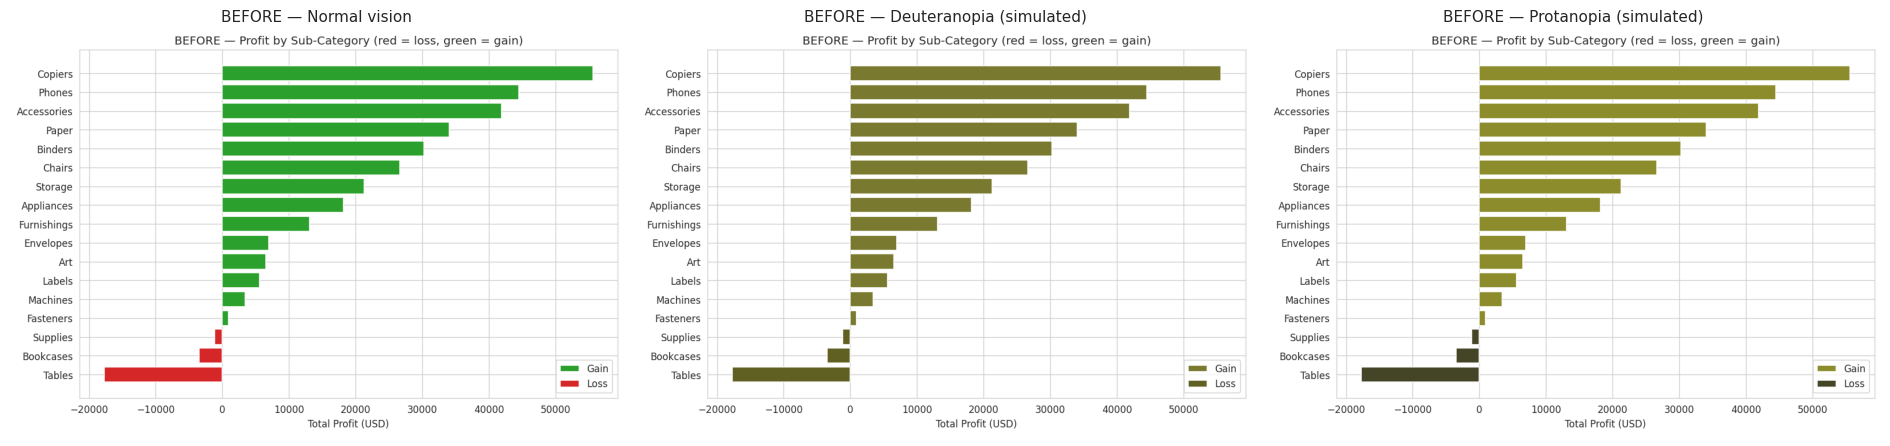

In [19]:
import matplotlib.image as mpimg

def simulate_cvd(img_rgb, kind='deuteranopia'):
    """Simulate color vision deficiency on an HxWx3 float array in [0,1]."""
    # sRGB -> LMS cone space
    rgb2lms = np.array([[0.31399022, 0.63951294, 0.04649755],
                        [0.15537241, 0.75789446, 0.08670142],
                        [0.01775239, 0.10944209, 0.87256922]])
    lms2rgb = np.linalg.inv(rgb2lms)

    # Dichromat projection matrices (Viénot et al.)
    sim = {
        'protanopia':   np.array([[0, 1.05118294, -0.05116099],
                                  [0, 1, 0],
                                  [0, 0, 1]]),
        'deuteranopia': np.array([[1, 0, 0],
                                  [0.9513092, 0, 0.04866992],
                                  [0, 0, 1]]),
        'tritanopia':   np.array([[1, 0, 0],
                                  [0, 1, 0],
                                  [-0.86744736, 1.86727089, 0]]),
    }[kind]

    lms = img_rgb @ rgb2lms.T
    lms_sim = lms @ sim.T
    out = lms_sim @ lms2rgb.T
    return np.clip(out, 0, 1)


def show_simulation(png_path, title_prefix):
    img = mpimg.imread(png_path)[:, :, :3].astype(float)
    if img.max() > 1.0:
        img = img / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(19, 6))
    for ax_, (label, arr) in zip(axes, [
            ('Normal vision', img),
            ('Deuteranopia (simulated)', simulate_cvd(img, 'deuteranopia')),
            ('Protanopia (simulated)',   simulate_cvd(img, 'protanopia'))]):
        ax_.imshow(arr)
        ax_.set_title(f'{title_prefix} — {label}', fontsize=11)
        ax_.axis('off')
        ax_.grid(False)
    plt.tight_layout()
    plt.show()


show_simulation('task4_before.png', 'BEFORE')

What the simulation shows. Under deuteranopia the red and green bars turn into the same muddy olive and become impossible to tell apart. Under protanopia a slight lightness difference remains, but nothing in the chart says which shade means loss. Either way the legend stops working, so a reader with red-green deficiency (about 8% of men) cannot tell a loss-making sub-category from a profitable one. The only clue left is which side of zero a bar sits on, and the legend actively misleads because both of its swatches now look the same.

The fix. Keep the colour, but add a second cue that does not depend on colour: hatching, plus value labels and a zero line, as the manual suggests.

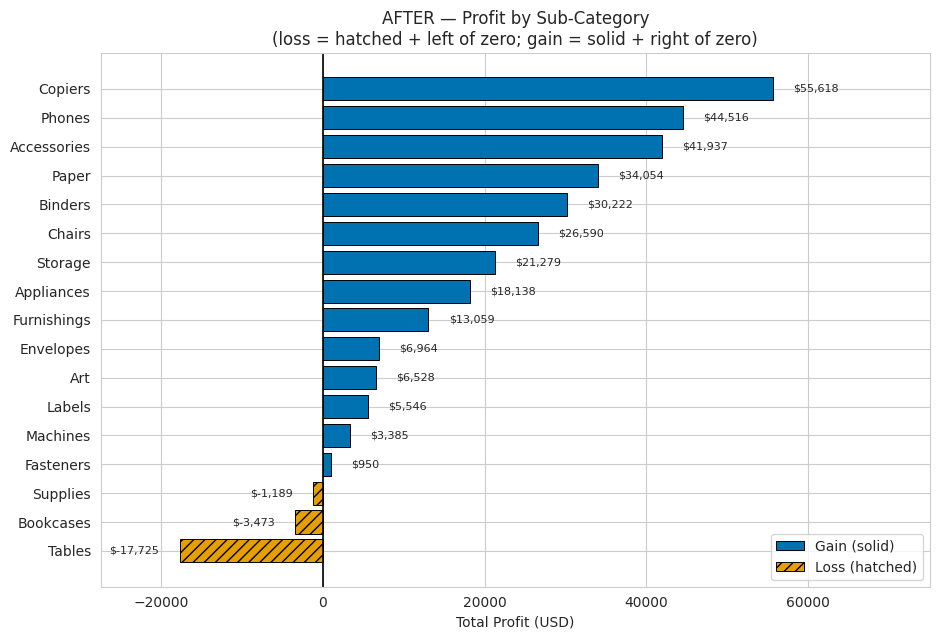

In [20]:
# --- AFTER: hatching + labels + zero line carry the meaning; color is redundant ---
BLUE, ORANGE = '#0072B2', '#E69F00'   # colorblind-safe pair, replacing red/green

fig, ax = plt.subplots(figsize=(9.5, 6.5))
gain_bar, loss_bar = None, None
for i, (name, v) in enumerate(subcat_profit.items()):
    is_loss = v < 0
    b = ax.barh(i, v,
                color=ORANGE if is_loss else BLUE,
                hatch='///' if is_loss else '',      # <-- the redundant channel
                edgecolor='black', linewidth=0.7)
    # Keep one bar of each kind to use as a legend handle later
    if is_loss:
        loss_bar = b[0]
    else:
        gain_bar = b[0]

ax.set_yticks(range(len(subcat_profit)))
ax.set_yticklabels(subcat_profit.index)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Total Profit (USD)')
ax.set_title('AFTER — Profit by Sub-Category\n(loss = hatched + left of zero; gain = solid + right of zero)')

for i, v in enumerate(subcat_profit.values):
    off = -2500 if v < 0 else 2500
    ax.text(v + off, i, f'${v:,.0f}', va='center',
            ha='right' if v < 0 else 'left', fontsize=8)
ax.set_xlim(subcat_profit.min() * 1.55, subcat_profit.max() * 1.35)

ax.legend([gain_bar, loss_bar], ['Gain (solid)', 'Loss (hatched)'], loc='lower right')

plt.tight_layout()
fig.savefig('task4_after.png', dpi=120, bbox_inches='tight')
plt.show()

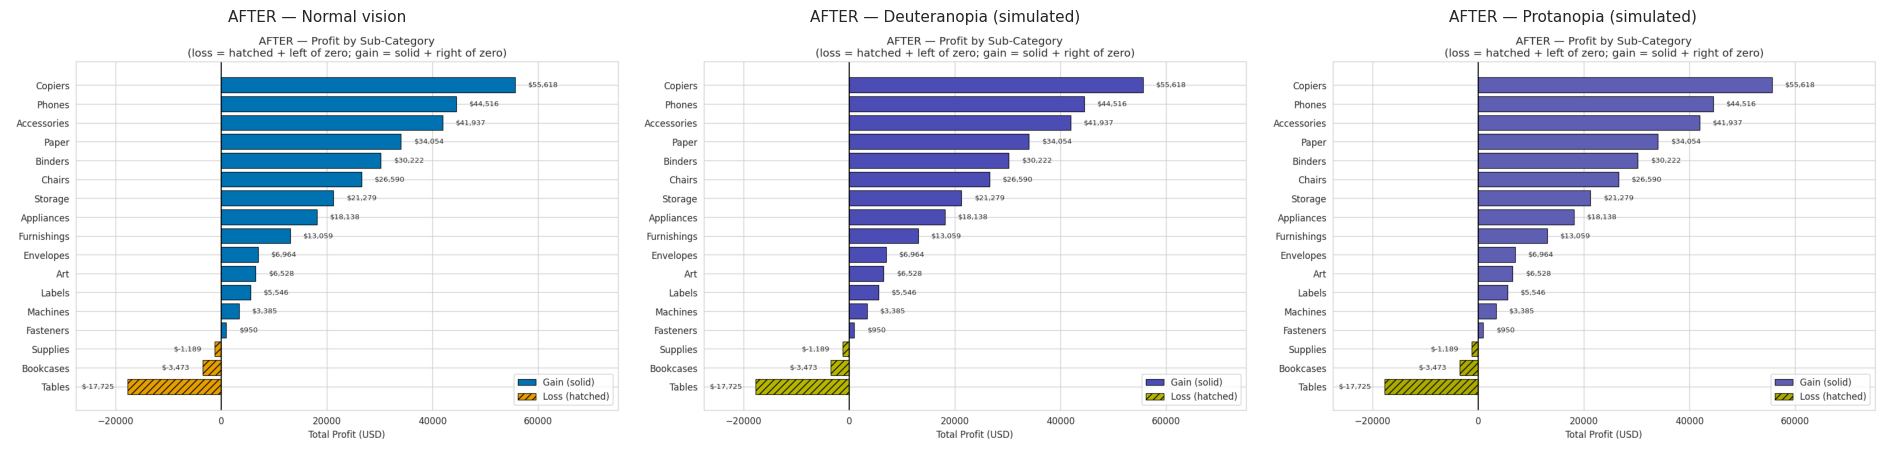

In [21]:
show_simulation('task4_after.png', 'AFTER')

Result. In the simulated views the blue and orange still look clearly different. Even if they did not, the hatching, the zero line, and the printed dollar values each show loss vs gain on their own. The chart survives the simulation, and would also survive being printed in greyscale or photocopied, which is the same problem in another form.

Alt text: Horizontal bar chart of total profit by product sub-category. Fourteen sub-categories are profitable, led by Copiers ($55,618), Phones ($44,516) and Accessories ($41,937). Three are loss-making: Tables (-$17,725), Bookcases (-$3,473) and Supplies (-$1,189), shown as hatched bars extending left of the zero line.

# Task 5

### 5.1 Truncated y-axis — region sales

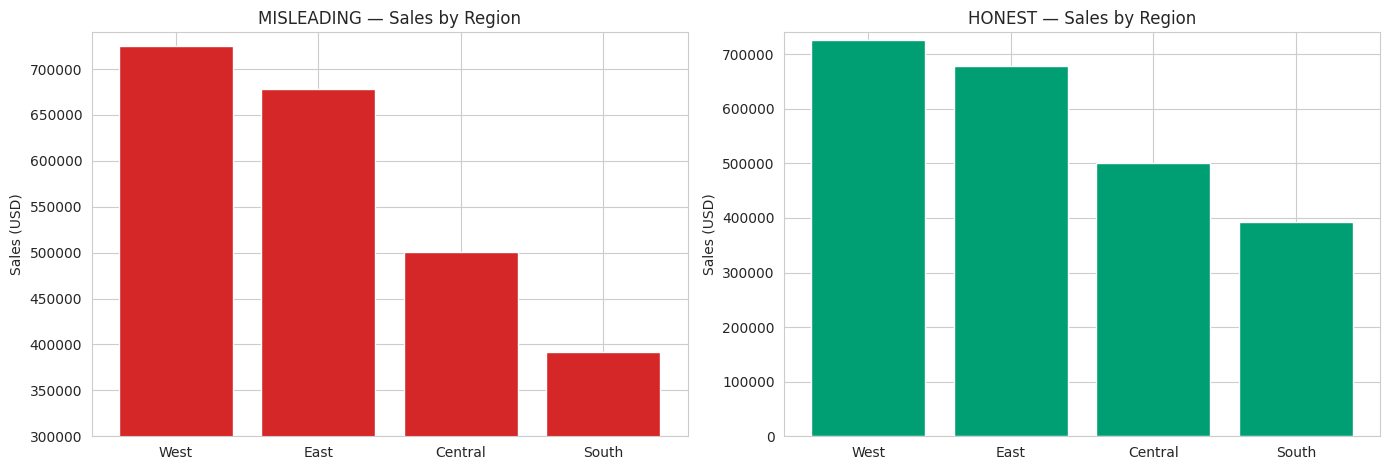

True ratio West : South = 1.85x


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# MISLEADING
axes[0].bar(region_sales.index, region_sales.values, color='#D62728')
axes[0].set_ylim(300000, 740000)          # <-- baseline cut away
axes[0].set_title('MISLEADING — Sales by Region')
axes[0].set_ylabel('Sales (USD)')

# HONEST
axes[1].bar(region_sales.index, region_sales.values, color='#009E73')
axes[1].set_ylim(0, 740000)
axes[1].set_title('HONEST — Sales by Region')
axes[1].set_ylabel('Sales (USD)')

plt.tight_layout()
plt.show()

ratio_true = region_sales['West'] / region_sales['South']
print(f"True ratio West : South = {ratio_true:.2f}x")

Caption. Distortion mechanism: truncated y-axis. The left chart starts the y-axis at 300,000 instead of 0. This makes the West bar look about 4.6 times taller than the South bar, when the actual sales only differ by about 1.85 times. Bar length only matches value when the axis starts at zero, so cutting the baseline turns a moderate gap into a dramatic one.

### 5.2 Dual y-axes — two unrelated measures

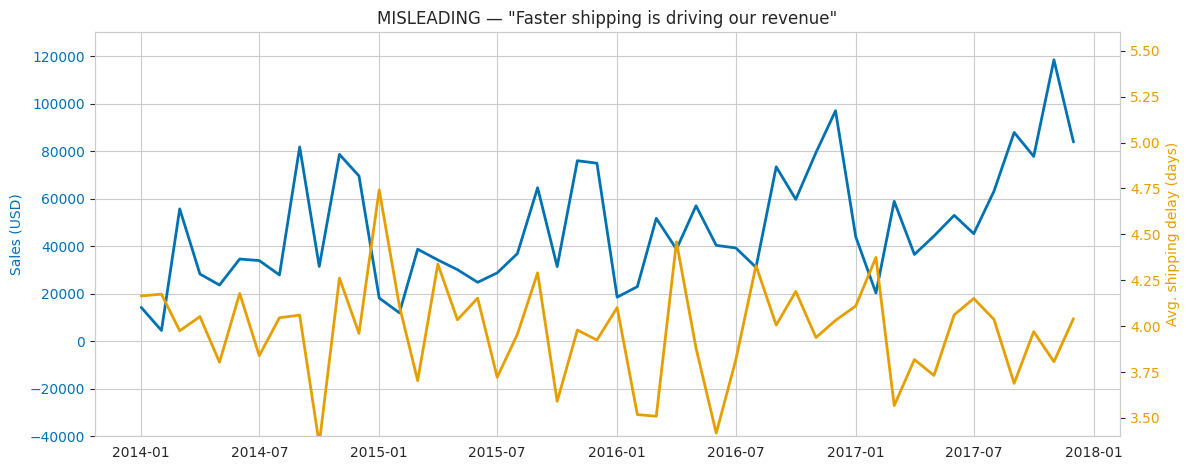

Actual correlation: -0.126


In [23]:
# Average shipping delay per month - a measure with no real link to revenue
df['ShipDelay'] = (df['Ship Date'] - df['Order Date']).dt.days
monthly_delay = df.groupby('Month')['ShipDelay'].mean()
monthly_delay.index = monthly_delay.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 4.8))
ax1.plot(monthly_sales.index, monthly_sales.values, color='#0072B2', linewidth=2)
ax1.set_ylabel('Sales (USD)', color='#0072B2')
ax1.set_ylim(-40000, 130000)                    # <-- scale chosen by hand to make the lines hug
ax1.tick_params(axis='y', labelcolor='#0072B2')

ax2 = ax1.twinx()
ax2.plot(monthly_delay.index, monthly_delay.values, color='#E69F00', linewidth=2)
ax2.set_ylabel('Avg. shipping delay (days)', color='#E69F00')
ax2.set_ylim(3.4, 5.6)                          # <-- and so is this one
ax2.tick_params(axis='y', labelcolor='#E69F00')
ax2.grid(False)

ax1.set_title('MISLEADING — "Faster shipping is driving our revenue"')
plt.tight_layout()
plt.show()

print("Actual correlation:", round(monthly_sales.corr(monthly_delay), 3))

Caption. Distortion mechanism: dual y-axes with hand-picked scales. The two lines are drawn on separate y-axes, and I set each range by hand until they appeared to follow each other. Their real correlation is about -0.13, basically none. Since the axis limits decide where each line sits, any two series can be made to look connected. The link comes from my settings, not the data.

### 5.3 Cherry-picked time window

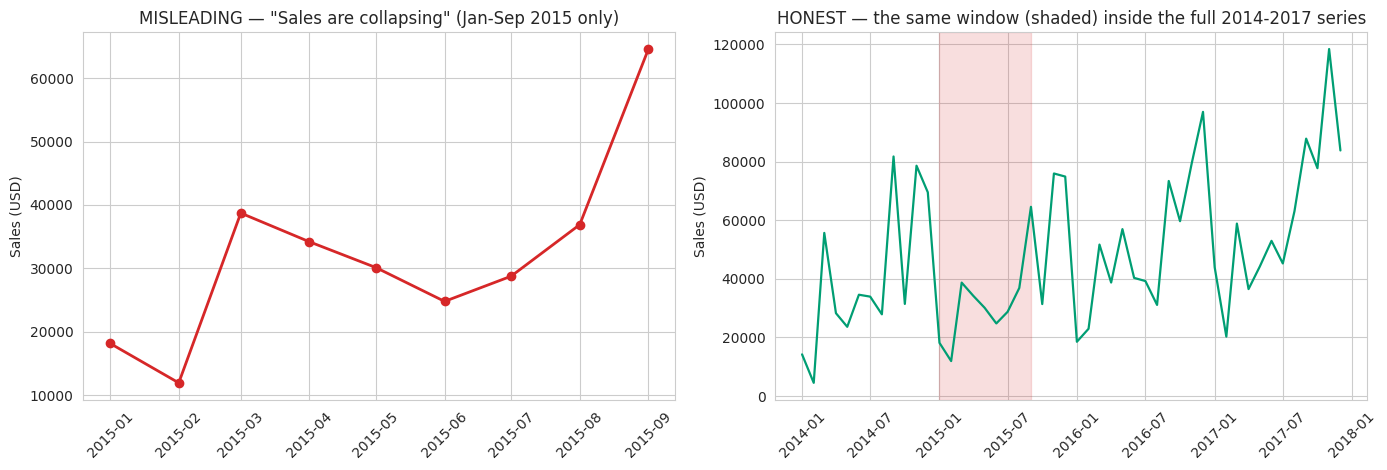

In [24]:
window = monthly_sales['2015-01':'2015-09']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(window.index, window.values, color='#D62728', marker='o', linewidth=2)
axes[0].set_title('MISLEADING — "Sales are collapsing" (Jan-Sep 2015 only)')
axes[0].set_ylabel('Sales (USD)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_sales.index, monthly_sales.values, color='#009E73', linewidth=1.6)
axes[1].axvspan(window.index[0], window.index[-1], color='#D62728', alpha=0.15)
axes[1].set_title('HONEST — the same window (shaded) inside the full 2014-2017 series')
axes[1].set_ylabel('Sales (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Caption. Distortion mechanism: cherry-picked time window. The left panel shows a nine-month slice chosen because it happens to end on a low point. On its own it looks like a collapse. The right panel highlights that same slice inside the full series, where it is just one of the dips that happen every year in a business that grew overall from 2014 to 2017. Nothing here is faked. The distortion comes from what was left out.

### 5.4 Inverted y-axis

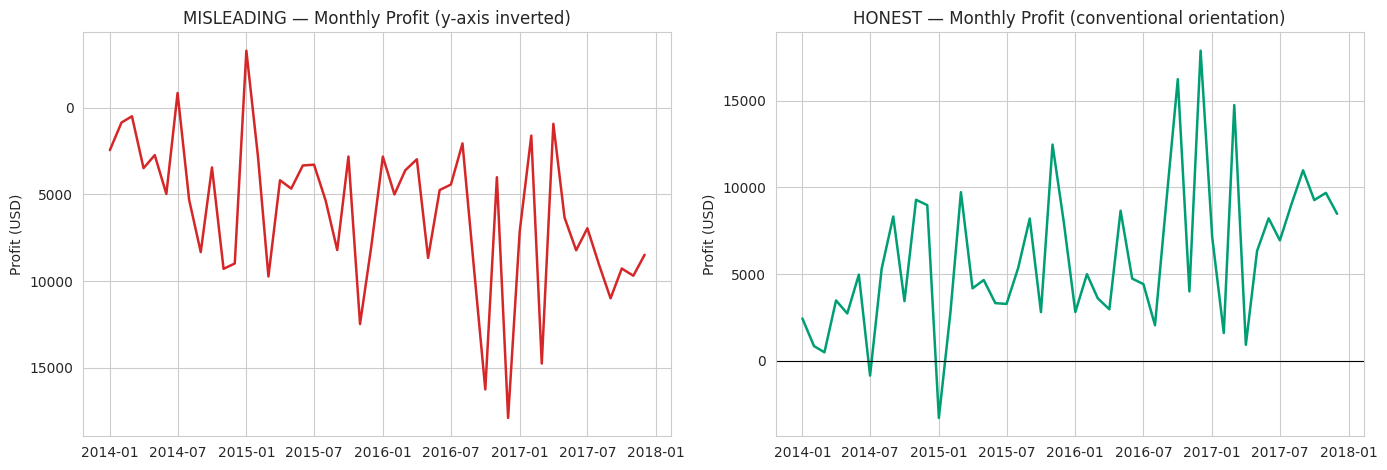

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(monthly_profit.index, monthly_profit.values, color='#D62728', linewidth=1.8)
axes[0].invert_yaxis()                      # <-- the trick
axes[0].set_title('MISLEADING — Monthly Profit (y-axis inverted)')
axes[0].set_ylabel('Profit (USD)')

axes[1].plot(monthly_profit.index, monthly_profit.values, color='#009E73', linewidth=1.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('HONEST — Monthly Profit (conventional orientation)')
axes[1].set_ylabel('Profit (USD)')

plt.tight_layout()
plt.show()

Caption. Distortion mechanism: inverted y-axis. The left chart flips the vertical axis, so loss-making months are drawn high and the most profitable months are drawn low. People assume "up means more" before they ever check the tick labels, so a month with a big loss looks like a peak. Every label is correct. The deception is in breaking the convention.

### 5.5 Bubble sized by radius instead of area

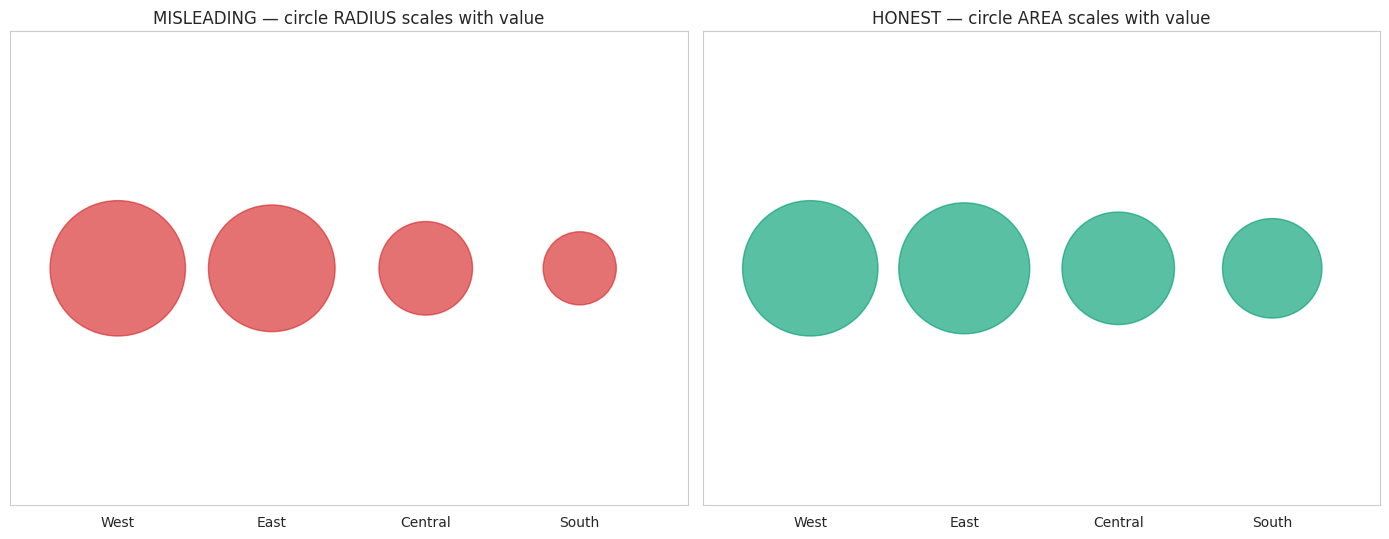

West is 1.85x South in sales.
Radius-scaled: West's circle has 3.43x the AREA of South's - the ratio is squared.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
vals = region_sales.values
x = np.arange(len(vals))

# MISLEADING: radius proportional to value  ->  area proportional to value^2
radius_scaled = (vals / vals.max()) * 55
axes[0].scatter(x, np.zeros_like(x), s=(radius_scaled ** 2) * np.pi,
                color='#D62728', alpha=0.65)
axes[0].set_title('MISLEADING — circle RADIUS scales with value')

# HONEST: area proportional to value  ->  radius proportional to sqrt(value)
area_scaled = (vals / vals.max()) * (55 ** 2) * np.pi
axes[1].scatter(x, np.zeros_like(x), s=area_scaled,
                color='#009E73', alpha=0.65)
axes[1].set_title('HONEST — circle AREA scales with value')

for ax_ in axes:
    ax_.set_xticks(x)
    ax_.set_xticklabels(region_sales.index)
    ax_.set_yticks([])
    ax_.set_ylim(-1, 1)
    ax_.set_xlim(-0.7, len(vals) - 0.3)
    ax_.grid(False)

plt.tight_layout()
plt.show()

r = region_sales['West'] / region_sales['South']
print(f"West is {r:.2f}x South in sales.")
print(f"Radius-scaled: West's circle has {r**2:.2f}x the AREA of South's - the ratio is squared.")

Caption. Distortion mechanism: bubble radius scaled by value instead of area. We judge a circle by how much space it takes up, which is its area, not its radius. If the radius is set to match the value, the area grows with the square of the value. So West, with about 1.85 times South's sales, ends up looking about 3.4 times bigger. The right panel scales the area instead, which means the radius follows the square root of the value. That is the correct way to do it.


# Task 6

In [27]:
# Profit behaviour at each discount level
by_disc = df.groupby('Discount').agg(
    mean_profit=('Profit', 'mean'),
    median_profit=('Profit', 'median'),
    n_orders=('Profit', 'size'),
    total_profit=('Profit', 'sum')
).reset_index()

by_disc['pct_of_orders'] = 100 * by_disc['n_orders'] / len(df)
by_disc.round(2)

,Discount,mean_profit,median_profit,n_orders,total_profit,pct_of_orders
0,0.00,66.90,16.00,4798,320987.60,48.01
1,0.10,96.06,54.32,94,9029.18,0.94
2,0.15,27.29,14.10,52,1418.99,0.52
3,0.20,24.70,6.49,3657,90337.31,36.59
4,0.30,-45.68,-25.38,227,-10369.28,2.27
5,0.32,-88.56,-46.98,27,-2391.14,0.27
6,0.40,-111.93,-57.62,206,-23057.05,2.06
7,0.45,-226.65,-167.32,11,-2493.11,0.11
8,0.50,-310.70,-185.28,66,-20506.43,0.66
9,0.60,-43.08,-12.06,138,-5944.66,1.38


### 6.1 The honest chart

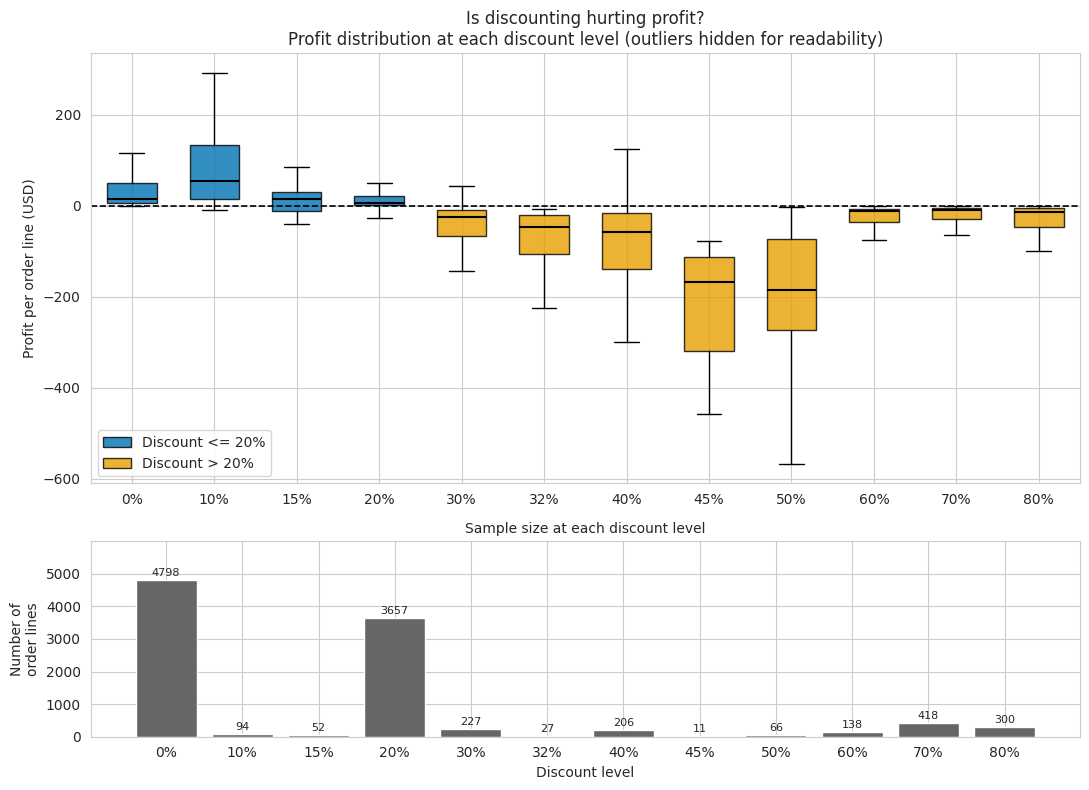

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=False,
                               gridspec_kw={'height_ratios': [2.2, 1]})

# --- Top: distribution of profit at each discount level ---
levels = sorted(df['Discount'].unique())
data_by_level = [df.loc[df['Discount'] == d, 'Profit'].values for d in levels]

bp = ax1.boxplot(data_by_level, positions=range(len(levels)), widths=0.6,
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color='black', linewidth=1.5))
for patch, d in zip(bp['boxes'], levels):
    patch.set_facecolor('#0072B2' if d <= 0.2 else '#E69F00')
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')

ax1.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax1.set_xticks(range(len(levels)))
ax1.set_xticklabels([f'{d:.0%}' for d in levels])
ax1.set_ylabel('Profit per order line (USD)')
ax1.set_title('Is discounting hurting profit?\n'
              'Profit distribution at each discount level (outliers hidden for readability)')
# patch_artist=True means bp['boxes'] holds real coloured shapes we can hand to legend().
# Levels are sorted, so the first box is 0% (blue) and the last is 80% (orange).
ax1.legend([bp['boxes'][0], bp['boxes'][-1]],
           ['Discount <= 20%', 'Discount > 20%'], loc='lower left')

# --- Bottom: how many orders sit at each level (essential context) ---
ax2.bar(range(len(levels)), by_disc['n_orders'], color='#666666')
ax2.set_xticks(range(len(levels)))
ax2.set_xticklabels([f'{d:.0%}' for d in levels])
ax2.set_xlabel('Discount level')
ax2.set_ylabel('Number of\norder lines')
ax2.set_title('Sample size at each discount level', fontsize=10)
for i, n in enumerate(by_disc['n_orders']):
    ax2.text(i, n + 120, str(n), ha='center', fontsize=8)
ax2.set_ylim(0, by_disc['n_orders'].max() * 1.25)

plt.tight_layout()
plt.show()

In [29]:
# The headline numbers behind the chart
low  = df[df['Discount'] <= 0.20]['Profit']
high = df[df['Discount'] >  0.20]['Profit']
print(f"Discount <= 20%:  {len(low):>5} lines, mean profit ${low.mean():>8.2f}, total ${low.sum():>12,.0f}")
print(f"Discount >  20%:  {len(high):>5} lines, mean profit ${high.mean():>8.2f}, total ${high.sum():>12,.0f}")
print(f"\nMean profit turns negative from the {by_disc.loc[by_disc.mean_profit < 0, 'Discount'].min():.0%} level onward.")

Discount <= 20%:   8601 lines, mean profit $   49.04, total $     421,773
Discount >  20%:   1393 lines, mean profit $  -97.18, total $    -135,376

Mean profit turns negative from the 30% level onward.


**Answer:** Yes, past a threshold. Order lines discounted at 20% or less are profitable on
average; from 30% upward the mean profit is negative at every level, and the losses deepen as the
discount grows. Discounting itself is not the problem — discounting *above about 20%* is.

### 6.2 The deliberately misleading version

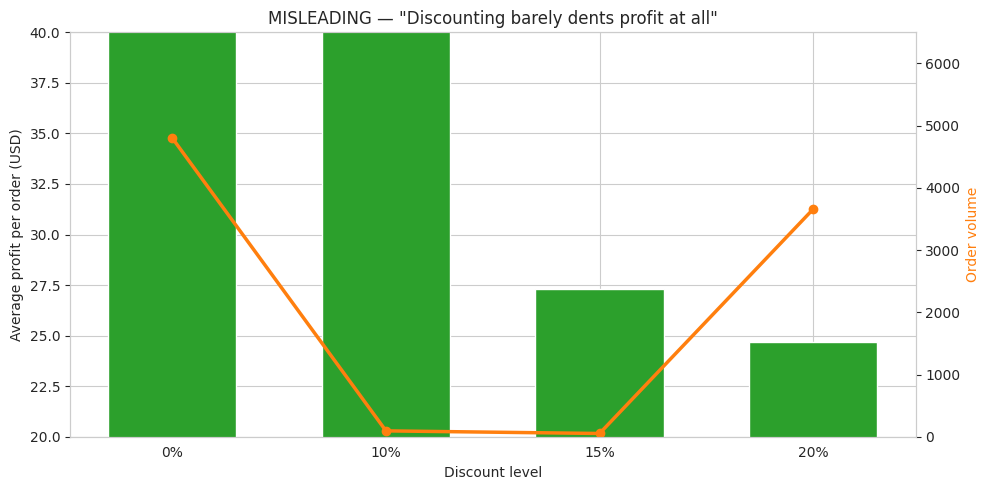

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

# Trick 1: drop every discount level above 20% (cherry-picked range)
subset = by_disc[by_disc['Discount'] <= 0.20]

# Trick 2: truncated y-axis
ax.bar(range(len(subset)), subset['mean_profit'], color='#2CA02C', width=0.6)
ax.set_ylim(20, 40)                      # <-- baseline cut away
ax.set_xticks(range(len(subset)))
ax.set_xticklabels([f'{d:.0%}' for d in subset['Discount']])
ax.set_xlabel('Discount level')
ax.set_ylabel('Average profit per order (USD)')
ax.set_title('MISLEADING — "Discounting barely dents profit at all"')

# Trick 3: unlabelled second axis implying discounting drives volume
ax2 = ax.twinx()
ax2.plot(range(len(subset)), subset['n_orders'], color='#FF7F0E',
         marker='o', linewidth=2.5)
ax2.set_ylabel('Order volume', color='#FF7F0E')
ax2.set_ylim(0, 6500)
ax2.grid(False)

plt.tight_layout()
plt.show()

Distortion mechanisms used:

1. Cherry-picked range. Every discount level above 20% is dropped. Those are the loss-making ones, so the bad news never shows up.
2. Truncated y-axis. The bars start at $20 instead of $0, which squashes the variation and makes the drop look small.
3. Dual y-axis. Order volume is put on its own scale so the line towers over the profit bars, hinting that discounts drive sales. The 0% bar has high volume because 0% is the default, not because discounting did anything.
4. Green colour. Green reads as "healthy" before anyone checks a number, and it is a colour that fails for red-green deficient readers.

### 6.3 Written justification

Chart type. The question is about how profit spreads out at each discount level, so I used a box plot per level instead of a bar of averages. Averages would hide the fact that profit is tight and positive at 0-20% but drops below zero and gets much more spread out from 30% up. That widening spread is part of the answer. Sample sizes are very uneven (4,798 lines at 0% but only 11 at 45%), so I added a count panel underneath. Without it, an 11-order box looks as trustworthy as a 4,798-order one. I avoided a line chart because discount is a few fixed tiers, not a smooth variable, so joining the points would suggest values in between that don't exist.

Colour choice. Blue (#0072B2) for 20% and under, orange (#E69F00) for above, marking where profit flips sign. It's a two-group split, so two clear colours work. I stayed away from red and green because the split is loss vs gain, which is exactly what red-green deficient readers cannot tell apart. The bottom panel is grey since counts are context, not the finding.

Accessibility check. Blue scores 5.19:1 against white and passes AA. Orange is 2.25:1 and fails for text, but it is only used as a large fill, and every box also has a black outline and median line. The finding does not rely on colour anyway: all the orange boxes sit right of the 20% mark and below the dashed zero line, so it still reads in greyscale and under both simulations.

Alt text: Box plot of profit per order line at each of the twelve discount levels, with a bar chart of order counts below. Profit sits above zero for discounts of 0-20%. From 30% upward the whole box is below zero, and the spread grows as the discount rises. Most orders are at 0% (4,798) and 20% (3,657).
